# Stage 1 — Faithfulness RD Analysis

This notebook analyses the Risk Difference (RD) results from the faithfulness pipeline.

**Condition contrast**: with-context vs no-context responses on SQuAD questions.

- **Positive RD** → expert more active when the model has context (faithful behaviour)
- **Negative RD** → expert more active when the model lacks context (confabulation behaviour)

Two RD variants are analysed:
- **Frequency-based RD**: based on how often each expert is selected (top-6)
- **Logit-based RD**: based on the mean raw gate logit score per expert

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from matplotlib.lines import Line2D

sys.path.insert(0, os.path.join('..', 'src'))
from rd_utils import load_rd

sns.set_theme(style='whitegrid', font='serif')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 150,
})

RD_FREQ_PATH  = '/scratch/sc23jc3/results/rd_faithfulness.json'
RD_LOGIT_PATH = '/scratch/sc23jc3/results/rd_faithfulness_logits.json'

In [2]:
rd_freq  = load_rd(RD_FREQ_PATH)
rd_logit = load_rd(RD_LOGIT_PATH)

layers_sorted = sorted(rd_freq.keys(), key=lambda x: int(x.split('.')[2]))
layer_indices = [int(l.split('.')[2]) for l in layers_sorted]
print(f'Layers: {len(layers_sorted)},  Experts per layer: {len(next(iter(rd_freq.values())))}')

Layers: 26,  Experts per layer: 64


## 1. RD Heatmap — Frequency-based

Each cell shows the RD for one (layer, expert) pair. Red = expert prefers with-context; blue = expert prefers no-context.

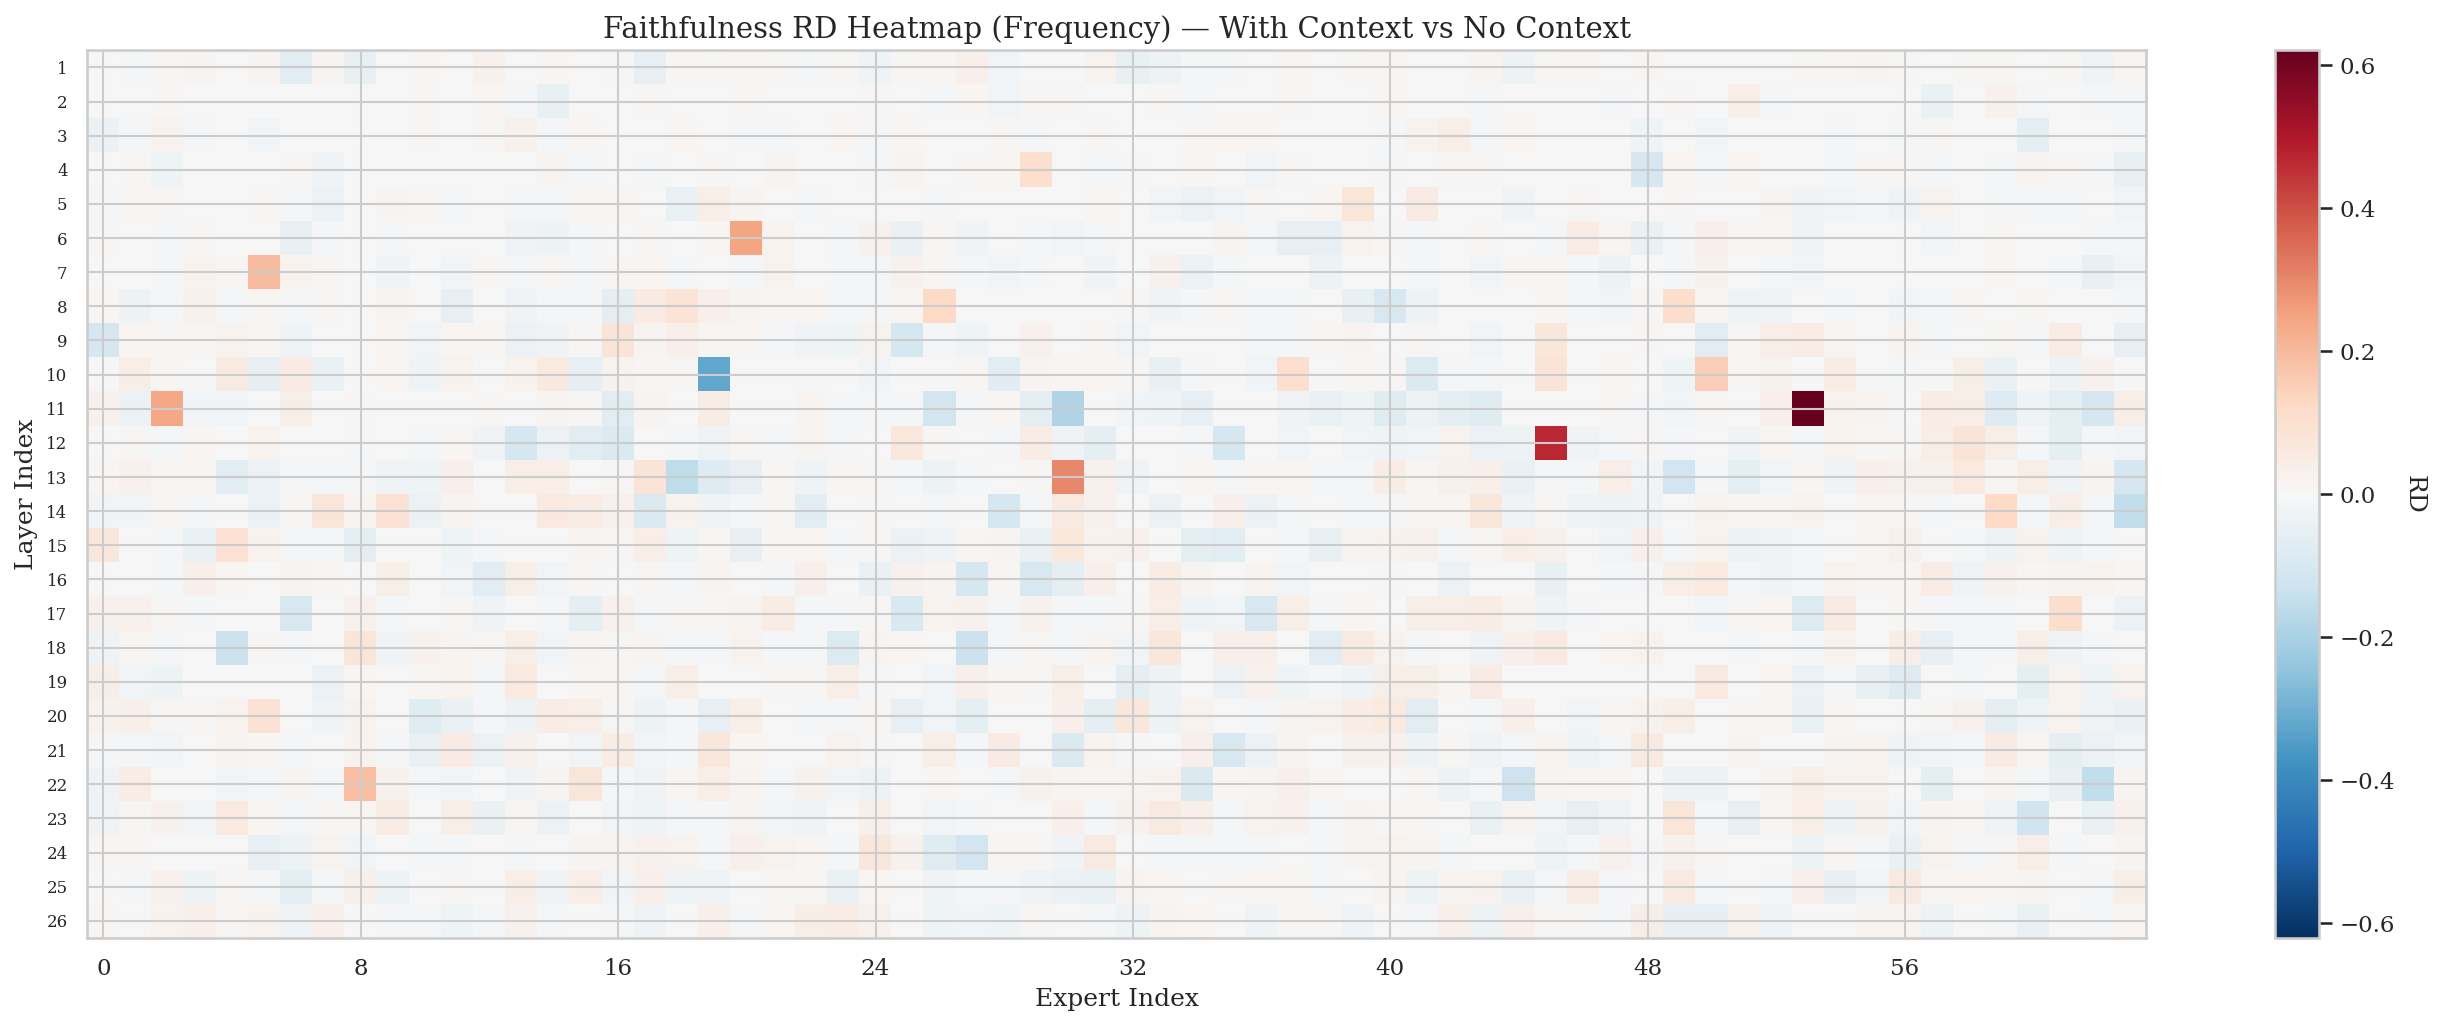

In [3]:
def plot_heatmap(rd_by_layer, layers_sorted, title):
    n_layers  = len(layers_sorted)
    n_experts = len(next(iter(rd_by_layer.values())))
    matrix = np.zeros((n_layers, n_experts))
    for i, layer in enumerate(layers_sorted):
        matrix[i] = rd_by_layer[layer]

    vmax = float(np.max(np.abs(matrix)))
    layer_labels = [int(l.split('.')[2]) for l in layers_sorted]

    fig, ax = plt.subplots(figsize=(18, 7))
    im = ax.imshow(matrix, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('RD', rotation=270, labelpad=15)
    ax.set_xlabel('Expert Index')
    ax.set_ylabel('Layer Index')
    ax.set_title(title)
    ax.set_yticks(range(n_layers))
    ax.set_yticklabels(layer_labels, fontsize=8)
    ax.set_xticks(range(0, n_experts, 8))
    plt.tight_layout()
    plt.show()

plot_heatmap(rd_freq, layers_sorted,
             'Faithfulness RD Heatmap (Frequency) — With Context vs No Context')

## 2. RD Heatmap — Logit-based

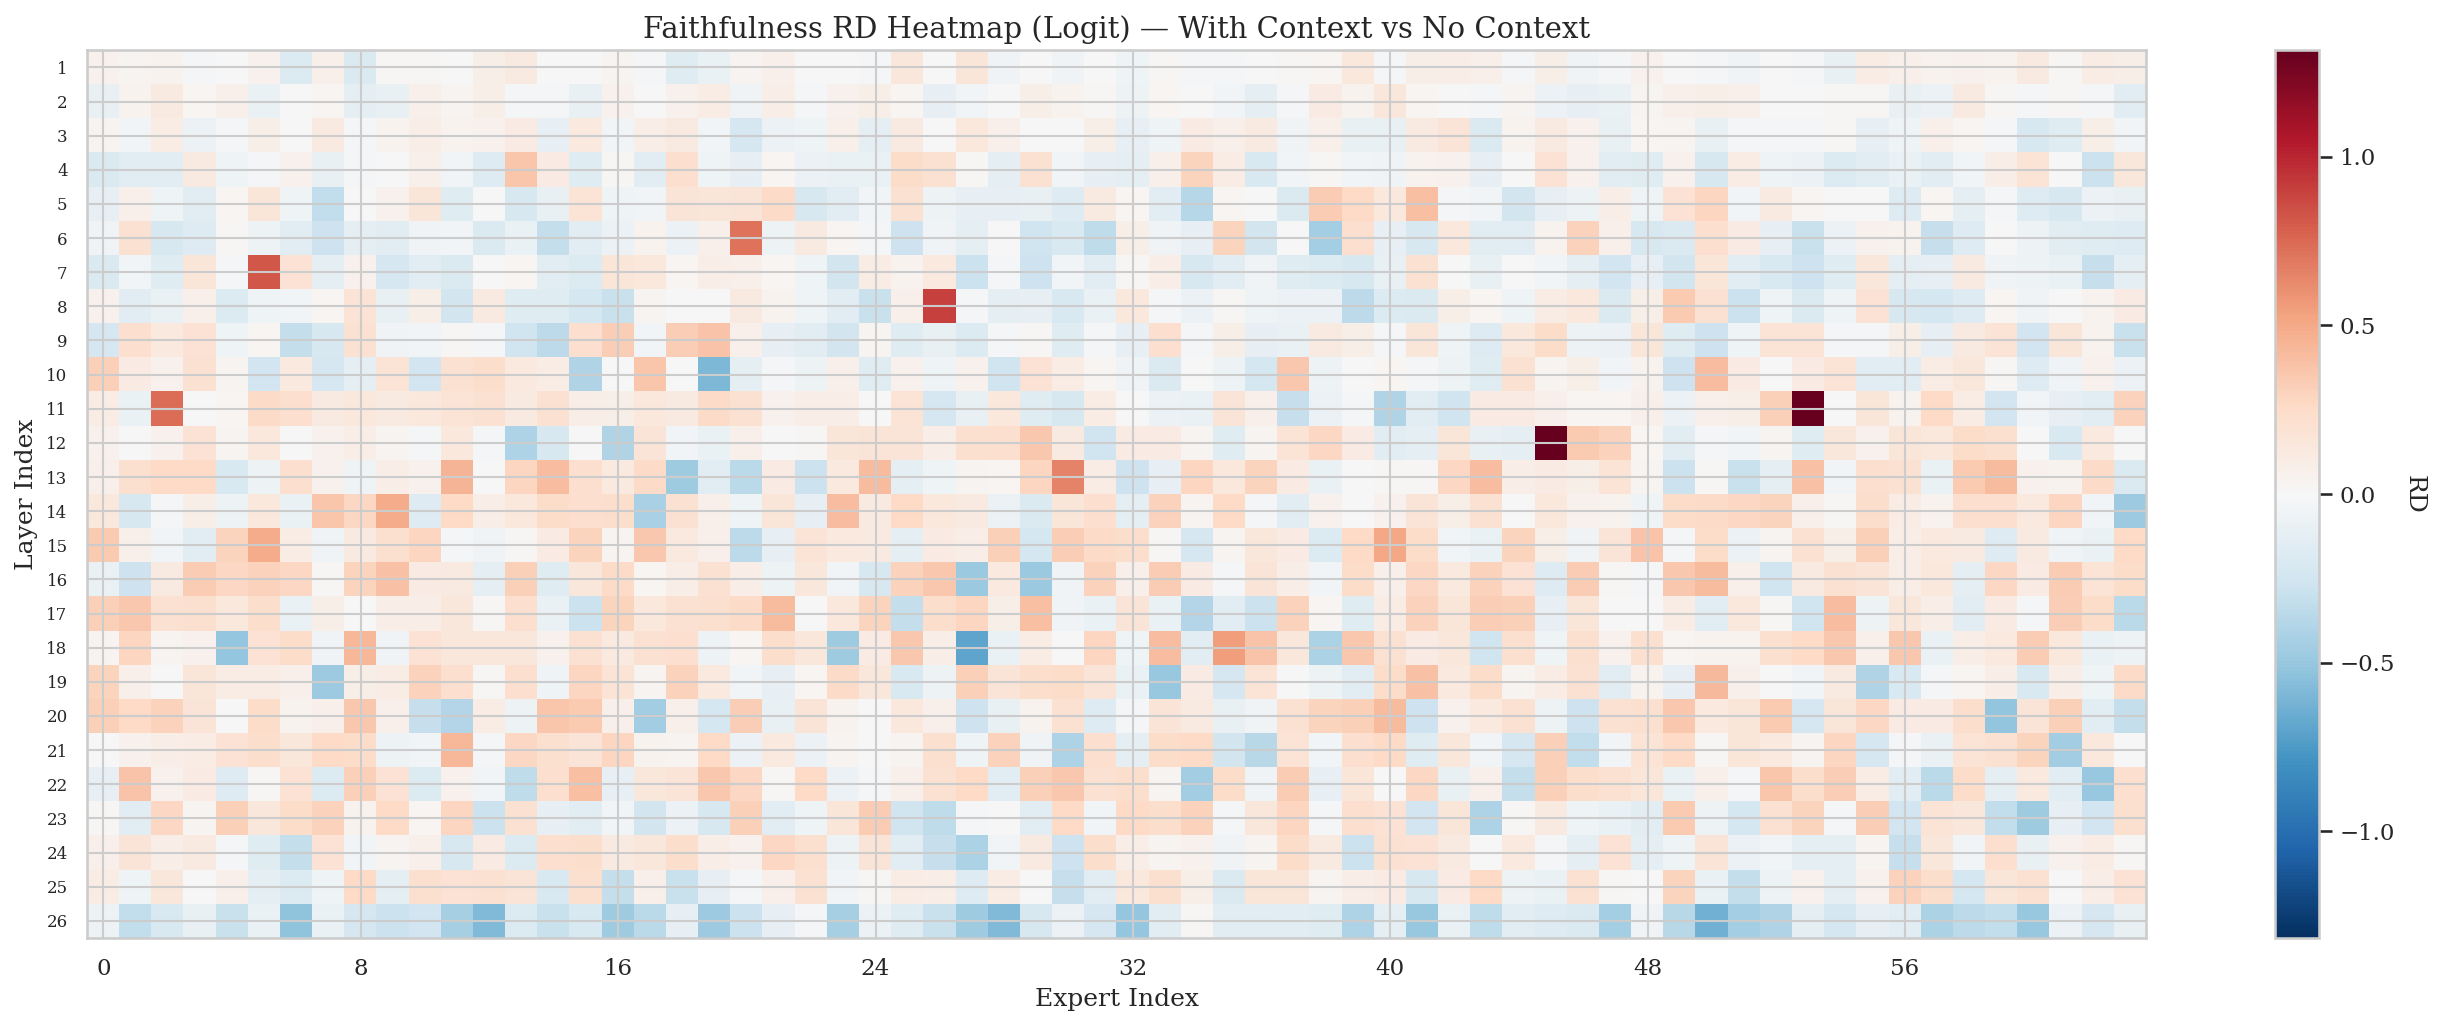

In [4]:
plot_heatmap(rd_logit, layers_sorted,
             'Faithfulness RD Heatmap (Logit) — With Context vs No Context')

## 3. Top Experts by |RD| — Frequency

In [5]:
import pandas as pd

def top_experts_table(rd_by_layer, top_n=20):
    rows = []
    for layer, rd in rd_by_layer.items():
        layer_idx = int(layer.split('.')[2])
        for expert_idx, val in enumerate(rd):
            rows.append((abs(val), val, layer_idx, expert_idx))
    rows.sort(reverse=True)
    df = pd.DataFrame([
        {'Rank': rank, 'Layer': f'L{layer}', 'Expert': f'e{expert}',
         'RD': round(val, 6), 'Direction': 'with-context' if val > 0 else 'no-context'}
        for rank, (_, val, layer, expert) in enumerate(rows[:top_n], 1)
    ]).set_index('Rank')
    return df.style.background_gradient(subset=['RD'], cmap='RdBu_r', vmin=-0.7, vmax=0.7) \
                   .format({'RD': '{:+.6f}'})

print('Top 20 by |RD| — Frequency')
top_experts_table(rd_freq)

Top 20 by |RD| — Frequency


,Layer,Expert,RD,Direction
Rank,,,,
1,L11,e53,+0.620646,with-context
2,L12,e45,+0.469799,with-context
3,L10,e19,-0.324864,no-context
4,L13,e30,+0.299297,with-context
5,L6,e20,+0.242729,with-context
6,L11,e2,+0.242410,with-context
7,L7,e5,+0.195909,with-context
8,L22,e8,+0.186961,with-context
9,L11,e30,-0.184883,no-context


## 4. Top Experts by |RD| — Logit

In [6]:
print('Top 20 by |RD| — Logit')
top_experts_table(rd_logit)

Top 20 by |RD| — Logit


,Layer,Expert,RD,Direction
Rank,,,,
1,L12,e45,+1.315379,with-context
2,L11,e53,+1.306544,with-context
3,L8,e26,+0.896977,with-context
4,L7,e5,+0.821920,with-context
5,L11,e2,+0.730270,with-context
6,L6,e20,+0.714091,with-context
7,L18,e27,-0.690353,no-context
8,L13,e30,+0.650349,with-context
9,L26,e50,-0.630268,no-context


## 5. Butterfly Scatter — Significant RD Experts (Frequency)

Each labelled dot is a (layer, expert) pair above the 90th percentile of |RD|. Expert index is printed inside the dot. x-position encodes RD magnitude; y-position is the layer (with small jitter to separate same-layer dots).

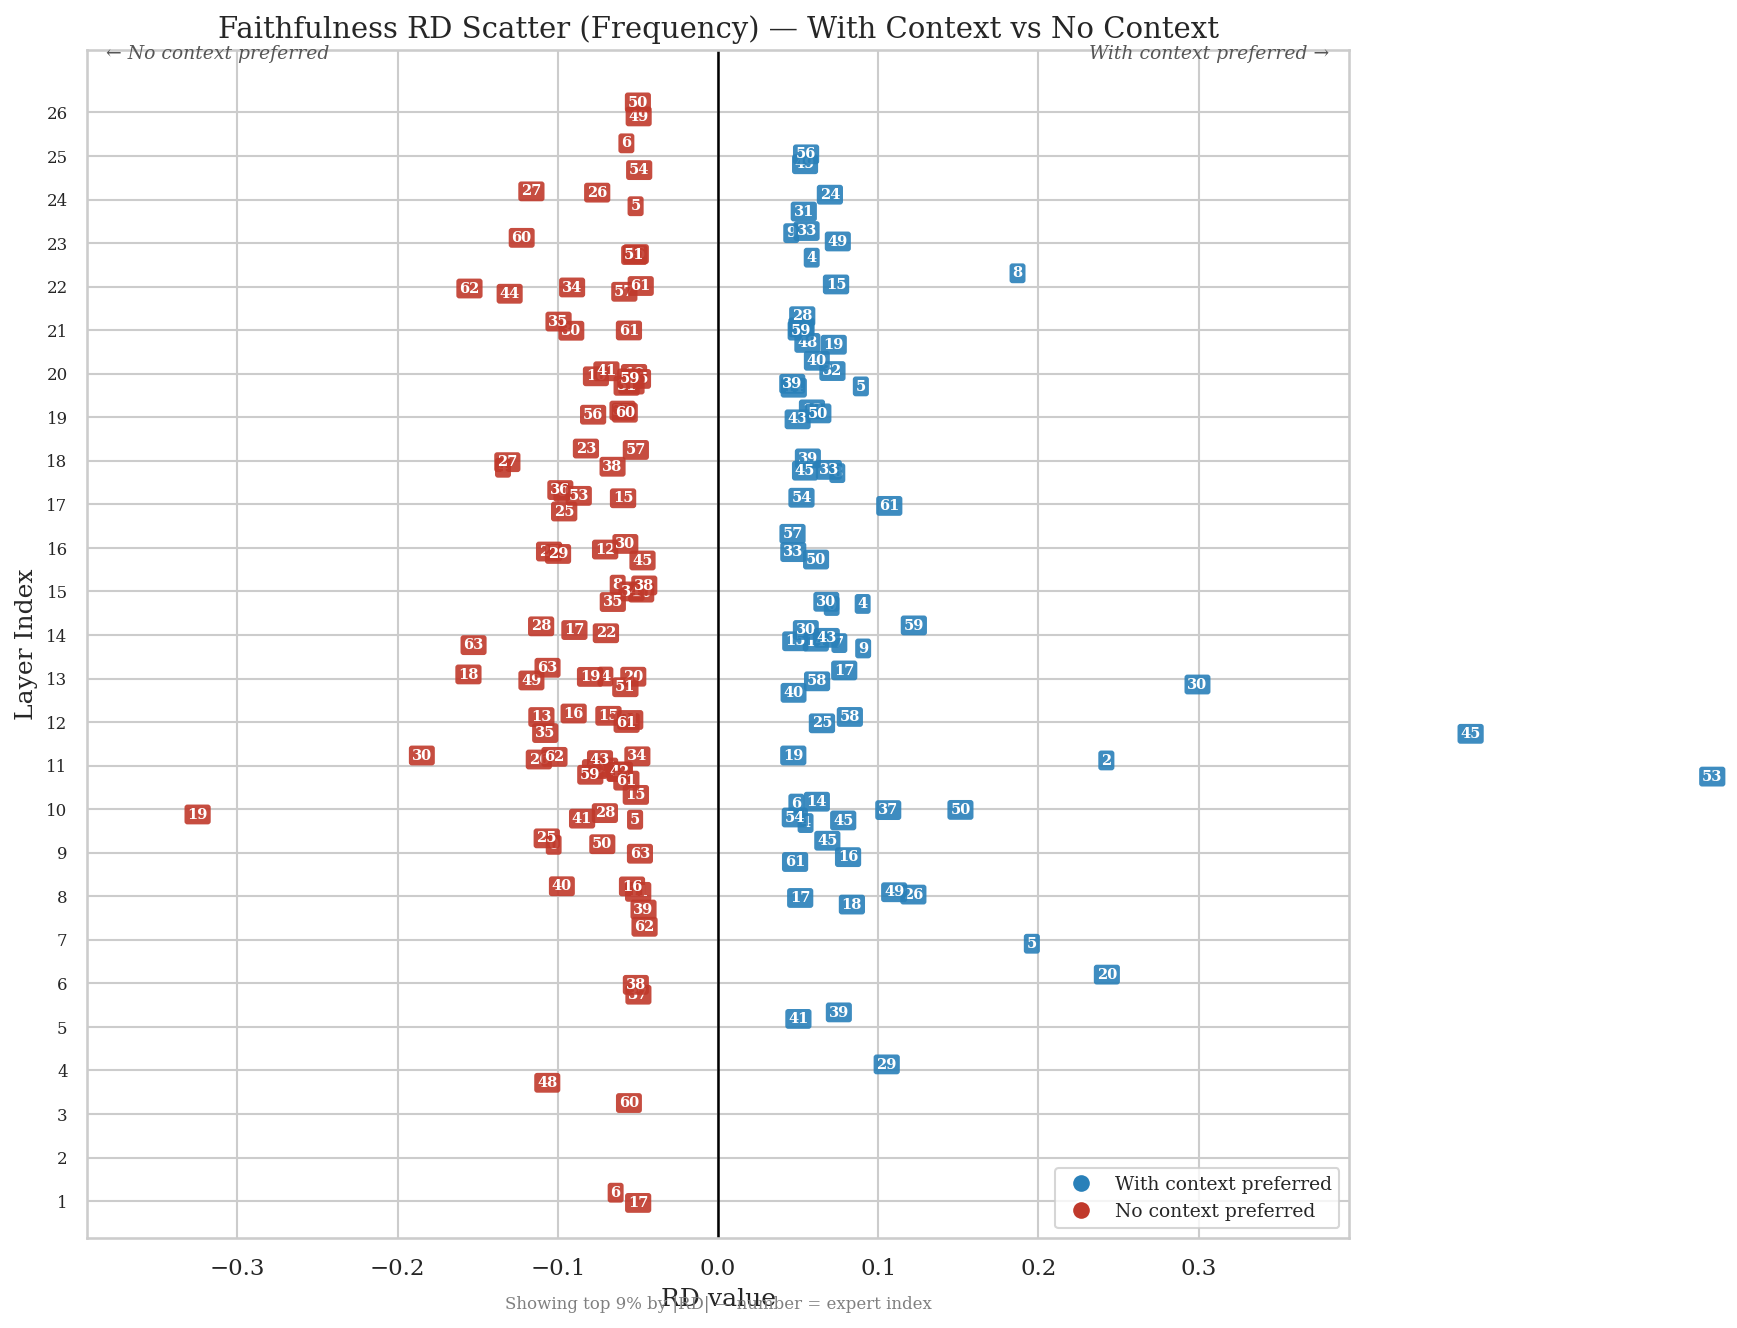

In [7]:
def plot_butterfly(rd_by_layer, layers_sorted, label_a, label_b, title,
                   threshold_quantile=0.90, color_a='#2980b9', color_b='#c0392b'):
    all_abs = np.concatenate([np.abs(rd) for rd in rd_by_layer.values()])
    threshold = np.quantile(all_abs, threshold_quantile)

    rng = np.random.default_rng(42)
    xs, ys, expert_labels, colors = [], [], [], []

    for layer in layers_sorted:
        layer_idx = int(layer.split('.')[2])
        rd = rd_by_layer[layer]
        for expert_idx in range(len(rd)):
            if abs(rd[expert_idx]) >= threshold:
                val = float(rd[expert_idx])
                xs.append(val)
                ys.append(layer_idx + rng.uniform(-0.35, 0.35))
                expert_labels.append(str(expert_idx))
                colors.append(color_a if val > 0 else color_b)

    x_max = float(np.percentile([abs(v) for v in xs], 98)) * 1.4
    layer_indices = [int(l.split('.')[2]) for l in layers_sorted]

    fig, ax = plt.subplots(figsize=(12, 9))
    for x, y, lbl, c in zip(xs, ys, expert_labels, colors):
        ax.text(x, y, lbl, ha='center', va='center',
                fontsize=7, color='white', fontweight='bold', zorder=3,
                bbox=dict(boxstyle='round,pad=0.2', facecolor=c, edgecolor='none', alpha=0.9))

    ax.axvline(0, color='black', linewidth=1.2, zorder=1)
    ax.set_xlim(-x_max, x_max)
    ax.set_ylim(min(ys) - 0.8, max(ys) + 1.2)
    ax.set_yticks(layer_indices)
    ax.set_yticklabels(layer_indices, fontsize=8)

    y_top = max(ys) + 0.9
    ax.text(-x_max * 0.97, y_top, f'← {label_b} preferred',
            ha='left', va='bottom', fontsize=9, color='#555555', style='italic')
    ax.text(x_max * 0.97, y_top, f'{label_a} preferred →',
            ha='right', va='bottom', fontsize=9, color='#555555', style='italic')

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=color_a, markersize=9, label=f'{label_a} preferred'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=color_b, markersize=9, label=f'{label_b} preferred'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
    ax.set_xlabel('RD value')
    ax.set_ylabel('Layer Index')
    ax.set_title(title)
    pct = int((1 - threshold_quantile) * 100)
    ax.text(0.5, -0.06, f'Showing top {pct}% by |RD| — number = expert index',
            transform=ax.transAxes, fontsize=8, ha='center', color='grey')
    plt.tight_layout()
    plt.show()

plot_butterfly(rd_freq, layers_sorted,
               label_a='With context', label_b='No context',
               title='Faithfulness RD Scatter (Frequency) — With Context vs No Context')

## 6. Butterfly Scatter — Significant RD Experts (Logit)

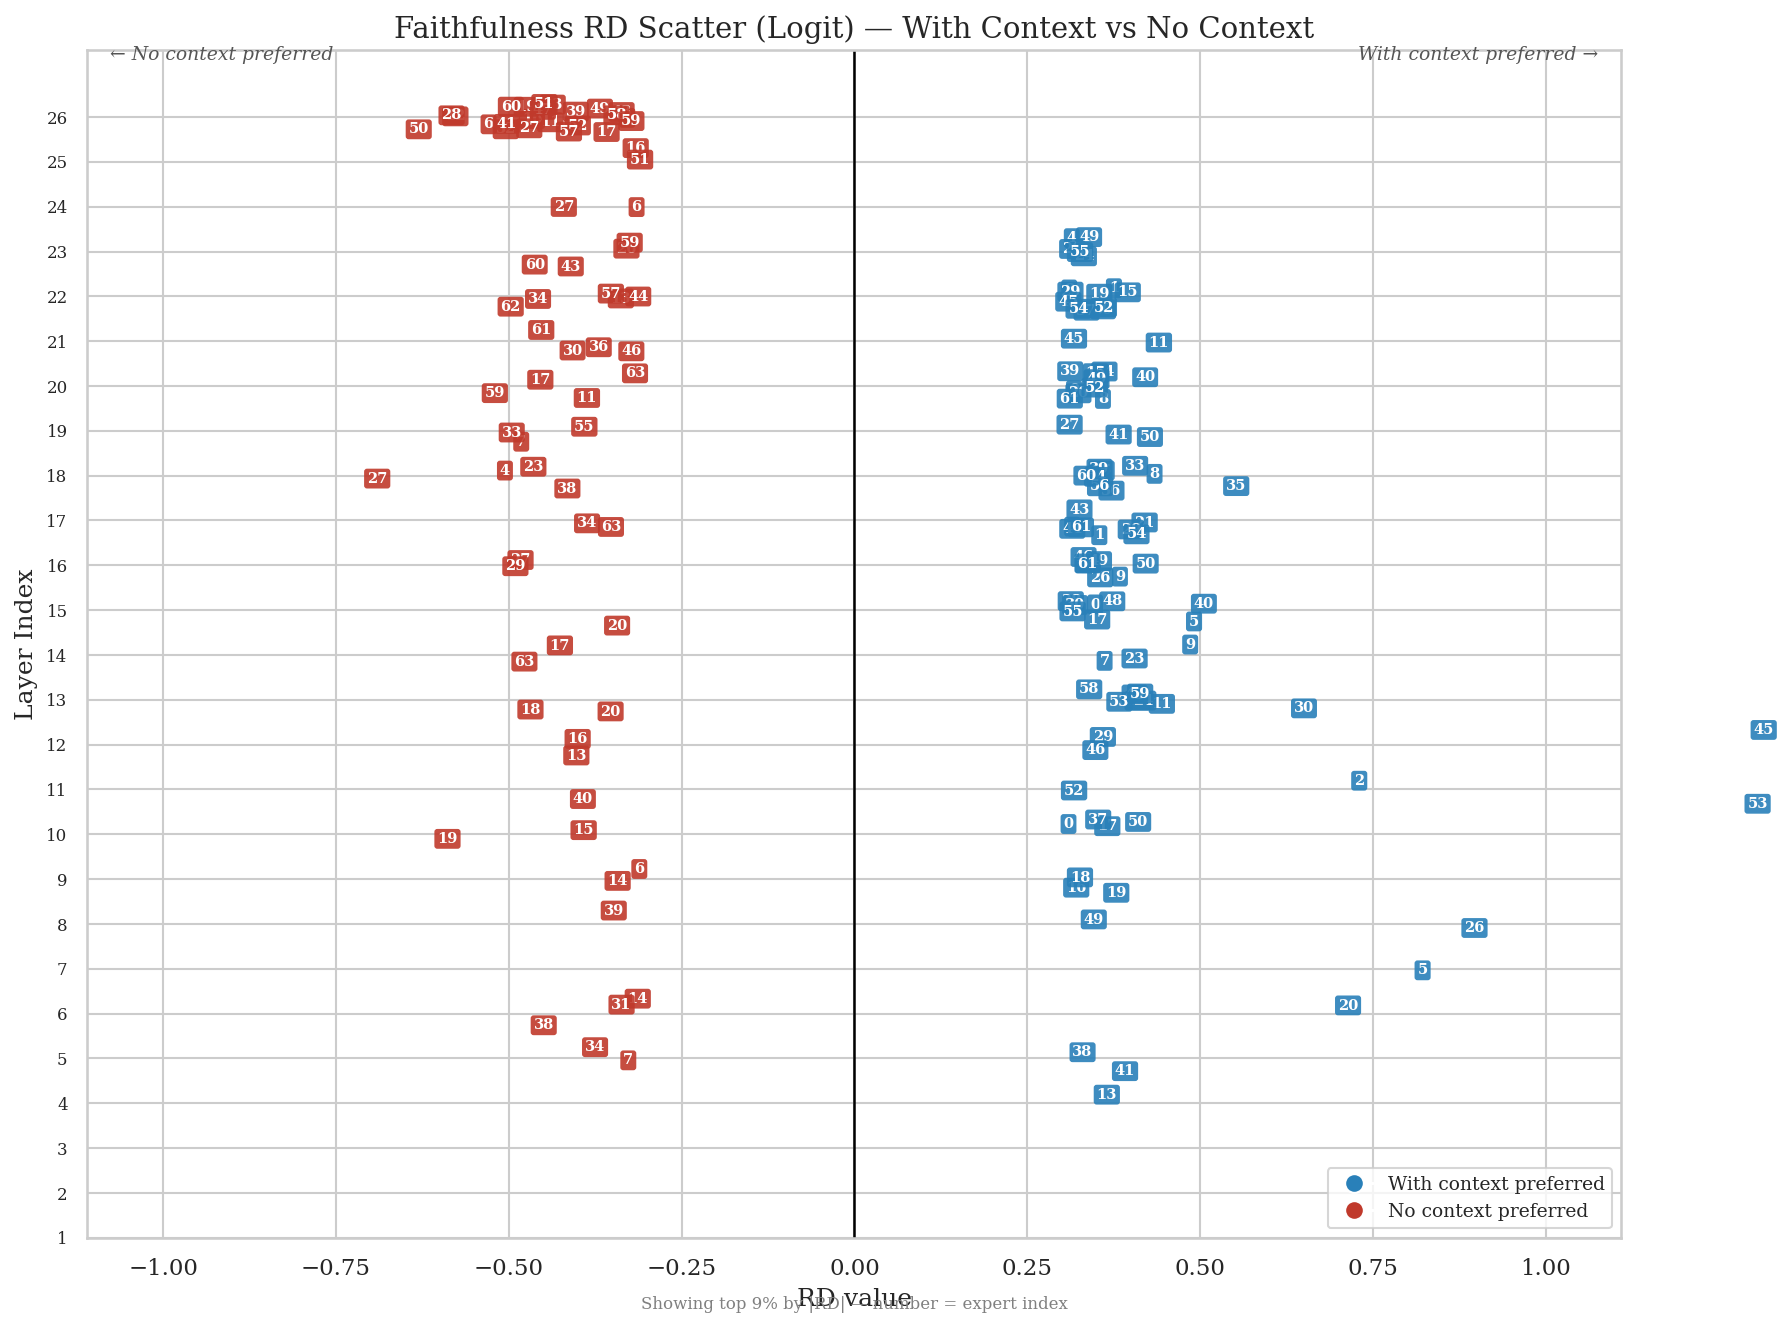

In [8]:
plot_butterfly(rd_logit, layers_sorted,
               label_a='With context', label_b='No context',
               title='Faithfulness RD Scatter (Logit) — With Context vs No Context')

## Discussion

- Which layers show the strongest RD signal?
- Are high-|RD| experts concentrated in specific layers or spread throughout the network?
- Is the frequency-based RD consistent with the logit-based RD?
- What does this suggest about where faithfulness behaviour is encoded in DeepSeek-V2-Lite?